# Uplift Promotions Model
- Justin Wall, Analytics Consultant, BlueWing Air

---
## Questions to answer
1. ...

## Load Data

In [1]:
import pandas as pd

df = pd.read_csv('../data/bluewing_air_promo_uplift.csv')

print(df.shape)
print('-------------------------------')
print(df.dtypes)
print('-------------------------------')
print(df.head())
print('-------------------------------')
print(df.describe())
print('-------------------------------')
print(df.groupby('treatment').agg({'converted': ['mean', 'sum']}))
print('-------------------------------')
print(df.groupby('treatment').agg({'customer_id': ['nunique']}))

(20000, 14)
-------------------------------
customer_id                    str
tenure_months                int64
loyalty_tier                   str
bookings_last_12mo           int64
days_since_last_booking    float64
avg_fare_last_year         float64
email_engagement_score     float64
treatment                    int64
converted                    int64
booking_revenue            float64
true_p_control             float64
true_p_treat               float64
true_uplift                float64
true_segment                   str
dtype: object
-------------------------------
  customer_id  tenure_months loyalty_tier  bookings_last_12mo  \
0  CUST000000              8       Silver                   3   
1  CUST000001             66       Silver                   1   
2  CUST000002             55        Basic                   0   
3  CUST000003             37        Basic                   1   
4  CUST000004             37        Basic                   2   

   days_since_last_booking  a

***
### **Notes**:
Campaign-level data, 20_000 customers, 2 treatment groups, conversion, loyalty tiers
***

## Data Alignment - Business

In [2]:
# Balance check
feature_cols = ['tenure_months', 'bookings_last_12mo', 'days_since_last_booking',
                'avg_fare_last_year', 'email_engagement_score']

# side-by-side means by arm - should look nearly identical if randomization worked
balance = df.groupby('treatment')[feature_cols].mean().T
balance['pct_diff'] = (balance[1] - balance[0]) / balance[0] * 100
print(balance)

# loyalty_tier is categorical - check mix instead of mean
print(pd.crosstab(df['loyalty_tier'], df['treatment'], normalize='columns'))

treatment                         0           1  pct_diff
tenure_months             42.157989   42.245372  0.207274
bookings_last_12mo         1.611172    1.632643  1.332612
days_since_last_booking   91.762746   90.045782 -1.871091
avg_fare_last_year       200.112016  200.608091  0.247899
email_engagement_score     0.446794    0.446855  0.013799
treatment            0         1
loyalty_tier                    
Basic         0.595883  0.587411
Gold          0.092635  0.105474
Silver        0.311482  0.307115


Randomization worked well here, no differences too large. Will still check the SMD for each feature for true balance.

In [3]:
# Standardized Mean Difference
# Convention for reading it:
# |SMD| < 0.1 = well balanced, 
# 0.1-0.25 = mild imbalance worth a mention, 
# >0.25 = actually worth investigating.
    
import numpy as np

def smd(treated, control):
    mean_diff = treated.mean() - control.mean()
    pooled_sd = np.sqrt((treated.var() + control.var()) / 2)
    return mean_diff / pooled_sd

balance = pd.DataFrame({
    'smd': [smd(df.loc[df.treatment==1, col], df.loc[df.treatment==0, col]) for col in feature_cols]
}, index=feature_cols)
print(balance)

                              smd
tenure_months            0.003609
bookings_last_12mo       0.014332
days_since_last_booking -0.018793
avg_fare_last_year       0.008757
email_engagement_score   0.000303


In [4]:
for tier in df['loyalty_tier'].unique():
    p_t = (df.loc[df.treatment==1, 'loyalty_tier'] == tier).mean()
    p_c = (df.loc[df.treatment==0, 'loyalty_tier'] == tier).mean()
    smd_tier = (p_t - p_c) / np.sqrt((p_t*(1-p_t) + p_c*(1-p_c)) / 2)
    print(f'{tier}: SMD = {smd_tier:.3f}')

Silver: SMD = -0.009
Basic: SMD = -0.017
Gold: SMD = 0.043


All features below 0.05, so we can be sure the groups were randomized and balanced properly, no known confounding variables.

In [5]:
# Aggregate lift

from statsmodels.stats.proportion import proportions_ztest

conv_control = df.loc[df['treatment'] == 0, 'converted']
conv_treat = df.loc[df['treatment'] == 1, 'converted']

n_control, n_treat = len(conv_control), len(conv_treat)
x_control, x_treat = conv_control.sum(), conv_treat.sum()

rate_control = x_control / n_control
rate_treat = x_treat / n_treat
abs_lift = rate_treat - rate_control
rel_lift = abs_lift / rate_control * 100

stat, pval = proportions_ztest([x_treat, x_control], [n_treat, n_control])

print(f"Control: {rate_control:.3%}  |  Treatment: {rate_treat:.3%}")
print(f"Absolute lift: {abs_lift:.3%}  |  Relative lift: {rel_lift:.1f}%")
print(f"z-stat: {stat:.2f}  |  p-value: {pval:.4f}")

Control: 20.905%  |  Treatment: 25.698%
Absolute lift: 4.793%  |  Relative lift: 22.9%
z-stat: 8.02  |  p-value: 0.0000


Treatment nearly 5pp higher than control. Proof of lift!

Text(0.5, 1.0, 'BlueWing Air Promo: Conversion Rate by Arm')

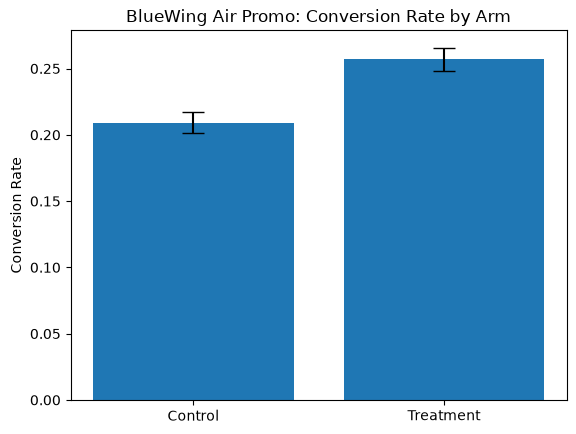

In [ ]:
# Conversion rate by arm with error bars
import matplotlib.pyplot as plt

rates = [rate_control, rate_treat]
# 95% CI half-width for each proportion
ci = [1.96 * np.sqrt(r*(1-r)/n) for r, n in zip(rates, [n_control, n_treat])]

plt.bar(['Control', 'Treatment'], rates, yerr=ci, capsize=8)
plt.ylabel('Conversion Rate')
plt.title('BlueWing Air Promo: Conversion Rate by Arm')

In [7]:
promo_cost = (df[df.treatment==1]['converted'] * df[df.treatment==1]['avg_fare_last_year'] * 0.15).sum()
incremental_bookings = (rate_treat - rate_control) * n_treat
incremental_revenue = incremental_bookings * df['avg_fare_last_year'].mean()
print(f"Discount cost from blanket send: ${promo_cost:,.0f}")
print(f"Estimated incremental revenue from lift: ${incremental_revenue:,.0f}")

Discount cost from blanket send: $78,941
Estimated incremental revenue from lift: $95,958


The campaign cost $78k in discounts and brought in an incremental $95k in revenue. Not all of these discounts went to people who needed them, some would have purchased anyway.

***
### **Notes**:
Campaign-level data, 20_000 customers, 2 treatment groups, conversion, loyalty tiers
***

## Data Alignment - Technical

EDA verifications before modeling

Worth checking:

Missing values / dtype sanity — quick df.info() + isnull().sum(), you already know it's clean but it's a 10-second check, not a step to skip out of confidence.
No post-treatment leakage in your feature list — this is the real one to verify carefully. booking_revenue is realized after the treatment/outcome decision (it's $0 for non-converters, and it's literally a function of converted and treatment). If it ends up in your feature list by accident, you're conditioning on a variable downstream of treatment — a classic causal inference trap. It should only ever appear as the thing you sum up in the policy backtest, never as an X column.
Confirm the true_ columns and customer_id are excluded* — already flagged, still worth a one-line assert in code (assert not any(c.startswith('true_') for c in feature_cols)) rather than eyeballing it.

Not worth doing — and I'd actively skip these:

Formal feature selection (Lasso, RFE, mutual information) — you have 5-6 features. Feature selection earns its keep when you're drowning in dozens/hundreds of candidates (like your MMM work). Here it's solving a problem you don't have.
Multicollinearity / VIF checks — this is a linear-regression concern. Every base learner in your plan is tree-based (XGBoost, causal forest, uplift trees). Trees split on one variable at a time and don't care if two features are correlated — VIF is checking for a failure mode that doesn't apply to your model family.

Cheap EDA add: naive heterogeneity check by loyalty tier, before any model. groupby(['loyalty_tier','w'])['converted'].mean() — this is a great scene-setter because it'll likely show Gold tier's lift looking flat or negative even in raw means, before you've built a single model. That's your "here's a hint something's off with our best customers" moment that the rest of the notebook goes on to formally confirm. Very cheap, high narrative payoff.

In [8]:
df.head()

,customer_id,tenure_months,loyalty_tier,bookings_last_12mo,days_since_last_booking,avg_fare_last_year,email_engagement_score,treatment,converted,booking_revenue,true_p_control,true_p_treat,true_uplift,true_segment
0,CUST000000,8,Silver,3,29.3,219.97,0.604,1,0,0.0,0.2700,0.2826,0.0126,lost_cause
1,CUST000001,66,Silver,1,252.9,265.71,0.389,0,0,0.0,0.0250,0.0100,-0.0314,lost_cause
2,CUST000002,55,Basic,0,487.7,264.89,0.313,0,0,0.0,0.0049,0.0100,-0.0145,lost_cause
3,CUST000003,37,Basic,1,121.2,124.57,0.253,0,0,0.0,0.0738,0.1174,0.0436,lost_cause
4,CUST000004,37,Basic,2,89.5,170.31,0.472,1,0,0.0,0.0829,0.1533,0.0704,persuadable


In [10]:
grouped = df.groupby('loyalty_tier').agg({'converted': ['mean','sum', 'count']})
grouped

converted             
                  mean   sum  count
loyalty_tier                       
Basic         0.174089  2060  11833
Gold          0.390207   773   1981
Silver        0.295344  1827   6186

***
### **Notes**:
Campaign-level data, 20_000 customers, 2 treatment groups, conversion, loyalty tiers
***

## Uplift Modeling

In [13]:
df.columns.to_list()

['customer_id',
 'tenure_months',
 'loyalty_tier',
 'bookings_last_12mo',
 'days_since_last_booking',
 'avg_fare_last_year',
 'email_engagement_score',
 'treatment',
 'converted',
 'booking_revenue',
 'true_p_control',
 'true_p_treat',
 'true_uplift',
 'true_segment']

In [16]:
from sklearn.model_selection import train_test_split

control = df.loc[df['treatment'] == 0]
treated = df.loc[df['treatment'] == 1]

converted = df['converted']

treatment = df['treatment']

booking_revenue = df['booking_revenue']

X = df[['tenure_months', 'loyalty_tier', 'bookings_last_12mo', 
        'days_since_last_booking', 'avg_fare_last_year', 'email_engagement_score']] 

In [ ]:
# Step 0: One shared setup

X_train, X_test, w_train, w_test, y_train, y_test, rev_train, rev_test = train_test_split(
    X, treatment, converted, booking_revenue, test_size=0.3, random_state=42
)
e = 0.5  # known propensity - it's a real 50/50 RCT, don't fit a propensity model

In [18]:
# Step 1: One results dataframe, built once

results = X_test.copy()
results['y'] = y_test
results['w'] = w_test
results['revenue'] = rev_test
# results['true_uplift'] = true_uplift_test   # your answer key
# results['true_segment'] = true_segment_test # your answer key

# each method below just adds one column here, e.g. results['tau_S'], results['tau_T'], etc.

In [19]:
# Step 2: S/T/X/R-learner + Doubly Robust — one loop, since they share an API

from causalml.inference.meta import BaseSLearner, BaseTLearner, BaseXLearner, BaseRLearner, BaseDRLearner
from xgboost import XGBRegressor

learners = {
    'S': BaseSLearner(learner=XGBRegressor()),
    'T': BaseTLearner(learner=XGBRegressor()),
    'X': BaseXLearner(learner=XGBRegressor()),
    'R': BaseRLearner(learner=XGBRegressor()),
    'DR': BaseDRLearner(learner=XGBRegressor()),
}
for name, learner in learners.items():
    learner.fit(X_train.values, w_train.values, y_train.values, p=e)  # p=known propensity
    results[f'tau_{name}'] = learner.predict(X_test.values)

c:\Users\wallj\DS_Projects\MarketingScience\uplift_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: could not convert string to float: 'Silver'

In [ ]:
# Step 3: Causal forest — its own block, gives you intervals too

from econml.dml import CausalForestDML
cf = CausalForestDML()
cf.fit(y_train, w_train, X=X_train)
results['tau_CF'] = cf.effect(X_test)

In [ ]:
# Step 4: Uplift trees — own block, remember the string-label quirk

w_train_str = w_train.map({0: 'control', 1: 'treatment1'})
uplift_rf = UpliftRandomForestClassifier(control_name='control')
uplift_rf.fit(X_train.values, treatment=w_train_str.values, y=y_train.values)
results['tau_UT'] = uplift_rf.predict(X_test.values)

In [ ]:
# Step 5: Evaluation — one call covers all 7 CATE methods at once

tau_cols = [c for c in results.columns if c.startswith('tau_')]
eval_df = results[tau_cols + ['y', 'w']]
plot_qini(eval_df, outcome_col='y', treatment_col='w')  # overlays all curves in one plot
qini_score(eval_df, outcome_col='y', treatment_col='w')  # one score per method

In [ ]:
# Step 6: Ground-truth segment check

results['true_segment'].value_counts()  # then eyeball, for your top CATE method, whether
# high tau_CF -> mostly true persuadables, negative tau_CF -> mostly true sleeping dogs

In [ ]:
# Step 7: Policy learning — the capstone

from econml.policy import PolicyTree
policy = PolicyTree(max_depth=3)
policy.fit(X_train, cf.effect(X_train))  # feed in your most-trusted CATE (probably causal forest)
recommended_treat = policy.predict(X_test)
# backtest: sum(revenue where recommended_treat matches actual w) vs. blanket-treat-everyone revenue